# ML

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from sklearn.preprocessing     import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics           import (accuracy_score, f1_score, roc_auc_score, auc , 
                                       confusion_matrix, classification_report,
                                       roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling    import SMOTE
import xgboost as xgb
from imblearn.pipeline         import Pipeline as ImbPipeline

In [9]:
df = pd.read_csv('clean_data.csv')
display(df.head(5))

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,...,Product Name,Product Price,shipping date (DateOrders),Shipping Mode,Order_process_time,delay,is_delay,order_month,order_day,order_hour
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,...,Smart watch,327.75,2018-02-03 22:56:00,Standard Class,3,-1,False,1,Wednesday,22
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,...,Smart watch,327.75,2018-01-18 12:27:00,Standard Class,5,1,True,1,Saturday,12
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,...,Smart watch,327.75,2018-01-17 12:06:00,Standard Class,4,0,False,1,Saturday,12
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,...,Smart watch,327.75,2018-01-16 11:45:00,Standard Class,3,-1,False,1,Saturday,11
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,...,Smart watch,327.75,2018-01-15 11:24:00,Standard Class,2,-2,False,1,Saturday,11


In [5]:
print(df['Late_delivery_risk'].value_counts()
)
print(df['Late_delivery_risk'].value_counts(normalize=True))

Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64
Late_delivery_risk
1    0.5729
0    0.4271
Name: proportion, dtype: float64


In [6]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Name', 'Customer Country',
       'Customer Segment', 'Customer Street', 'Department Id',
       'Department Name', 'order date (DateOrders)',
       'Order Item Product Price', 'Order Item Profit Ratio', 'Sales',
       'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order_process_time', 'delay', 'is_delay',
       'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [11]:
df.shape

(172765, 30)

In [20]:
df['is_weekend'] = df['order_day'].isin(['Saturday', 'Sunday']).astype(int)
df['is_peak_hour'] = df['order_hour'].between(9, 18).astype(int)

# Frequency Encoding (for high-cardinality)
freq_cols = ['Order Region', 'Category Name']

for col in freq_cols:
    freq_map = df[col].value_counts(normalize=True)
    df[col + "_freq"] = df[col].map(freq_map)

In [23]:
df = df.drop(columns = freq_cols)

In [25]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Customer Country', 'Customer Segment',
       'Customer Street', 'Department Id', 'Department Name',
       'order date (DateOrders)', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Sales', 'Order Profit Per Order',
       'Order Status', 'Product Name', 'Product Price',
       'shipping date (DateOrders)', 'Shipping Mode', 'Order_process_time',
       'delay', 'is_delay', 'order_month', 'order_day', 'order_hour',
       'is_weekend', 'is_peak_hour', 'Order Region_freq',
       'Category Name_freq'],
      dtype='object')

In [27]:
drop_col = ['Days for shipping (real)' , 'Days for shipment (scheduled)' , 'Benefit per order' , 'Sales per customer' , 'Delivery Status' ,'Customer Country' , 'Customer Street','Department Id' , 'order date (DateOrders)', 'Order Item Product Price','Order Item Profit Ratio', 'Sales', 'Order Profit Per Order','Order Status', 'Product Name', 'Product Price','shipping date (DateOrders)','Order_process_time',
'delay', 'is_delay' , 'order_day']
df = df.drop(columns = drop_col)

In [28]:
df.columns

Index(['Type', 'Late_delivery_risk', 'Customer Segment', 'Department Name',
       'Shipping Mode', 'order_month', 'order_hour', 'is_weekend',
       'is_peak_hour', 'Order Region_freq', 'Category Name_freq'],
      dtype='object')

In [29]:
df.to_csv('ml_dataset.csv' , index=False)

In [13]:
#  BUILD PIPELINES  (Preprocessor → SMOTE → Model)
#     Using imblearn Pipeline so SMOTE only runs on training folds

pipelines = {
 
    "Logistic Regression": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote",  SMOTE(random_state=42, k_neighbors=2)),
        ("model",  LogisticRegression(C=0.1, max_iter=1000,
                                      class_weight="balanced", random_state=42)),
    ]),
 
    "Random Forest": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote",  SMOTE(random_state=42, k_neighbors=2)),
        ("model",  RandomForestClassifier(n_estimators=200, max_depth=4,
                                          class_weight="balanced", random_state=42)),
    ]),
 
    "XGBoost": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote",  SMOTE(random_state=42, k_neighbors=2)),
        ("model",  xgb.XGBClassifier(n_estimators=200, max_depth=3,
                                     learning_rate=0.05, subsample=0.8,
                                     colsample_bytree=0.8, eval_metric="logloss",
                                     random_state=42, verbosity=0)),
    ]),
}

for name , pipe in pipelines.items():
    print(f"train : {name}")
    pipe.fit(x_train , y_train)
    print(f"model : {name} trained sucessfully")

train : Logistic Regression
model : Logistic Regression trained sucessfully
train : Random Forest
model : Random Forest trained sucessfully
train : XGBoost
model : XGBoost trained sucessfully


In [14]:
results = []
for name , pipe in pipelines.items():
    y_pred = pipe.predict(x_test)
    accuracy =  accuracy_score(y_test , y_pred)
    y_pred_proba = pipe.predict_proba(x_test)[:,1]
    roc_auc = roc_auc_score(y_test , y_pred_proba)
    report = classification_report(y_test , y_pred , output_dict=True)

    results.append({
        'Model'     : name,
        'Precision' : round(report['1']['precision'], 4),
        'Recall'    : round(report['1']['recall'],    4),
        'F1-Score'  : round(report['1']['f1-score'],  4), # i need to understand this 
        'AUC-ROC'   : round(roc_auc, 4)
    })

    print(f"model : {name}")
    # print(f"prediction : {y_pred}")
    print(f"accuracy : {accuracy}")
    print(f"ROC_AUC : {roc_auc}")
    print(f"{'='*45}")
    print(f"classification report : \n {classification_report(y_test , y_pred)}")
    print(f"{'='*45}")
    print("confusion matrix:")
    print(confusion_matrix(y_test , y_pred))
    print(f"{'='*45} \n ")

model : Logistic Regression
accuracy : 1.0
ROC_AUC : 1.0
classification report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     22137
           1       1.00      1.00      1.00     29693

    accuracy                           1.00     51830
   macro avg       1.00      1.00      1.00     51830
weighted avg       1.00      1.00      1.00     51830

confusion matrix:
[[22137     0]
 [    0 29693]]
 
model : Random Forest
accuracy : 0.9605440864364267
ROC_AUC : 0.9968526211434787
classification report : 
               precision    recall  f1-score   support

           0       1.00      0.91      0.95     22137
           1       0.94      1.00      0.97     29693

    accuracy                           0.96     51830
   macro avg       0.97      0.95      0.96     51830
weighted avg       0.96      0.96      0.96     51830

confusion matrix:
[[20092  2045]
 [    0 29693]]
 
model : XGBoost
accuracy : 1.0
ROC_AUC : 1.0
classific

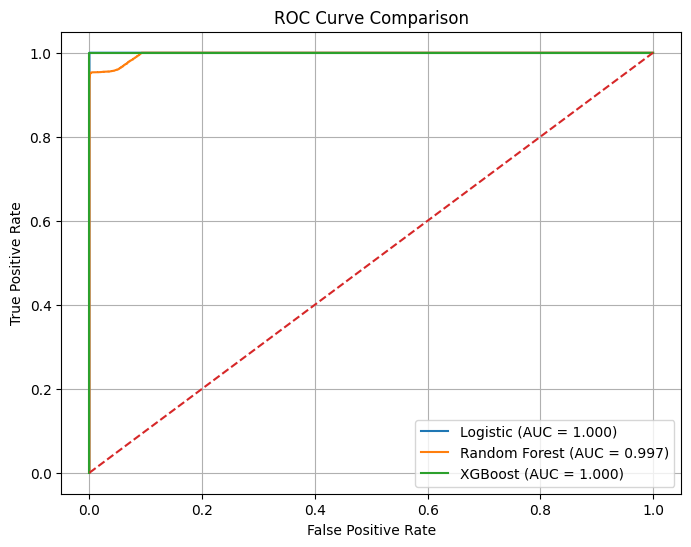

In [15]:
# get probability
log_prob = pipelines['Logistic Regression'].predict_proba(x_test)[:,1]

rf_prob = pipelines['Random Forest'].predict_proba(x_test)[:,1]

xgb_prob = pipelines['XGBoost'].predict_proba(x_test)[:,1]

# ROC curve
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_rf, tpr_rf, _   = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

# AUC score
auc_log = auc(fpr_log, tpr_log)
auc_rf  = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

Total features after encoding: 98


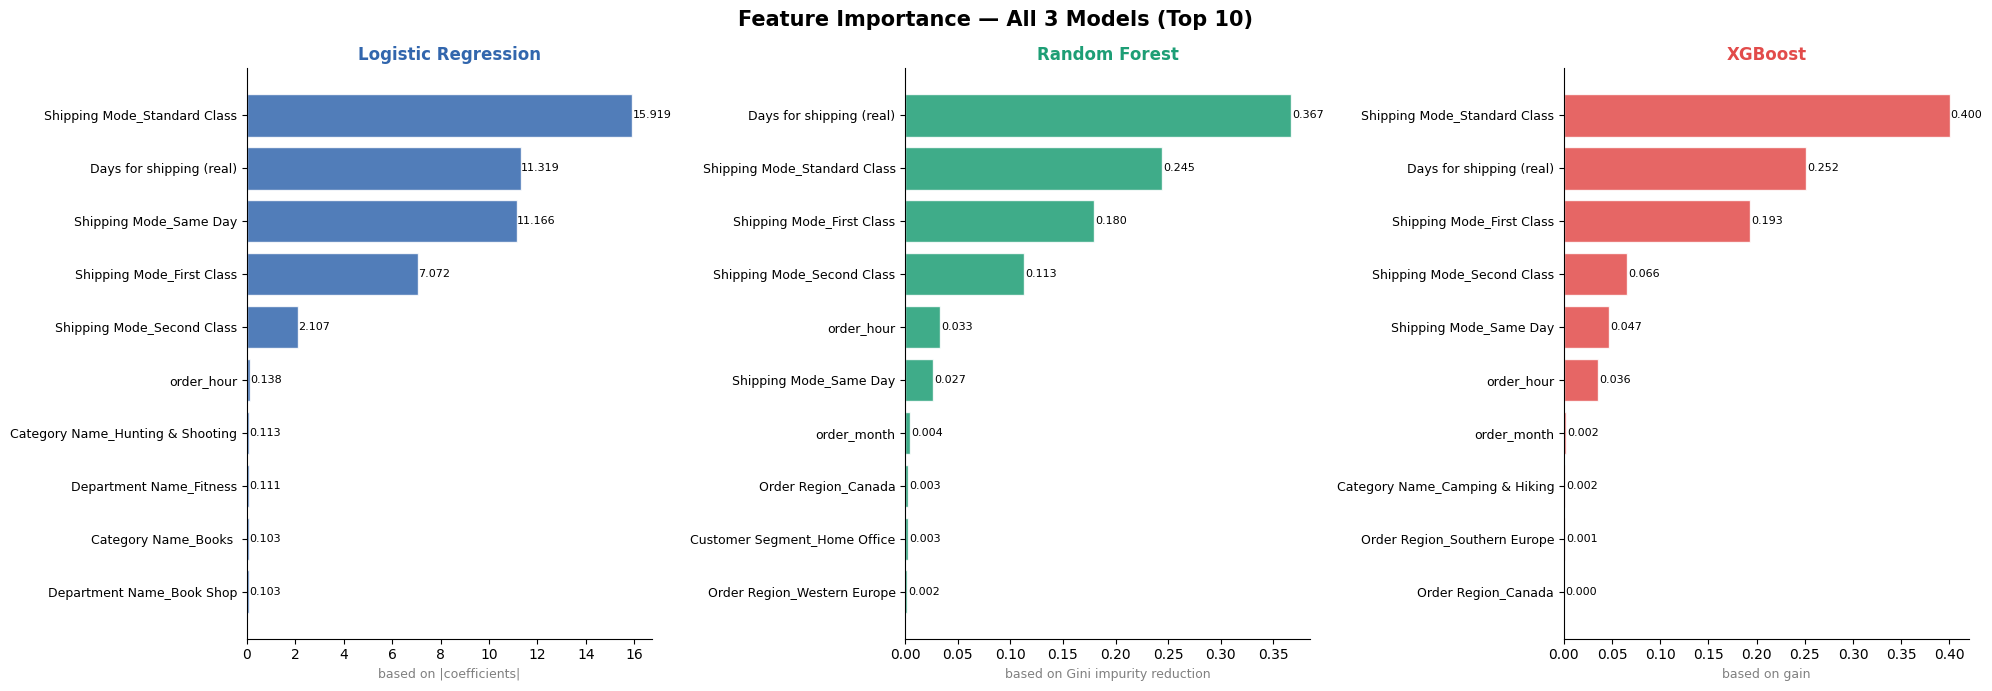

In [16]:
# Step 1: Get feature names AFTER preprocessing (OHE expands categorical cols)
ohe_feature_names = (pipelines["Logistic Regression"]
                     .named_steps["preprocessor"]
                     .named_transformers_["cat"]
                     .get_feature_names_out(categorical_col)
                     .tolist())

all_feature_names = numeric_col + ohe_feature_names
print(f"Total features after encoding: {len(all_feature_names)}")

# Step 2: Extract importance scores for each model
def get_importance(pipeline, model_name, feature_names):
    model = pipeline.named_steps["model"]
    
    if model_name == "Logistic Regression":
        # LR uses coefficients — take absolute value (magnitude = importance)
        scores = np.abs(model.coef_[0])
    
    elif model_name == "Random Forest":
        # RF has built-in feature_importances_ (Gini impurity based)
        scores = model.feature_importances_
    
    elif model_name == "XGBoost":
        # XGBoost has built-in feature_importances_ (gain based)
        scores = model.feature_importances_

    return pd.DataFrame({
        "feature"   : feature_names,
        "importance": scores
    }).sort_values("importance", ascending=False).reset_index(drop=True)

importance_dict = {}
for name, pipe in pipelines.items():
    importance_dict[name] = get_importance(pipe, name, all_feature_names)

# Step 3: Plot — Top 10 features per model
model_colors = {
    "Logistic Regression": "#3266ad",
    "Random Forest"      : "#1d9e75",
    "XGBoost"            : "#e24b4a",
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Feature Importance — All 3 Models (Top 10)", 
             fontsize=15, fontweight="bold")

for ax, (name, imp_df) in zip(axes, importance_dict.items()):
    top10 = imp_df.head(10).iloc[::-1]   # reverse so highest bar is on top
    
    bars = ax.barh(top10["feature"], top10["importance"],
                   color=model_colors[name], alpha=0.85, edgecolor="white")
    
    # value labels on bars
    for bar in bars:
        ax.text(bar.get_width() + 0.001, 
                bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.3f}", 
                va="center", fontsize=8)

    ax.set_title(name, fontsize=12, fontweight="bold", color=model_colors[name])
    ax.set_xlabel("Importance Score" if name == "Logistic Regression" 
                  else "Feature Importance", fontsize=10)
    ax.tick_params(axis="y", labelsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # subtitle explaining what importance means for this model
    subtitles = {
        "Logistic Regression": "based on |coefficients|",
        "Random Forest"      : "based on Gini impurity reduction",
        "XGBoost"            : "based on gain",
    }
    ax.set_xlabel(subtitles[name], fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("feature_importance_all_models.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
print("\n===== CROSS VALIDATION (ROC-AUC) =====\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, pipe in pipelines.items():
    scores = cross_val_score(
        pipe,
        x,
        y,
        cv=skf,
        scoring='roc_auc'
    )
    
    cv_results.append({
        "Model": name,
        "Mean ROC-AUC": scores.mean(),
        "Std Dev": scores.std()
    })
    
    print(f"{name}")
    print(f"Scores: {scores}")
    print(f"Mean ROC-AUC: {scores.mean():.4f}")
    print(f"Std Dev: {scores.std():.4f}")
    print("-"*40)

cv_results_df = pd.DataFrame(cv_results).sort_values(by="Mean ROC-AUC", ascending=False)
print("\nFinal CV Comparison:")
print(cv_results_df)


===== CROSS VALIDATION (ROC-AUC) =====

Logistic Regression
Scores: [1. 1. 1. 1. 1.]
Mean ROC-AUC: 1.0000
Std Dev: 0.0000
----------------------------------------
Random Forest
Scores: [0.99820781 0.99620109 0.99936214 0.99627837 0.99906579]
Mean ROC-AUC: 0.9978
Std Dev: 0.0013
----------------------------------------
XGBoost
Scores: [1. 1. 1. 1. 1.]
Mean ROC-AUC: 1.0000
Std Dev: 0.0000
----------------------------------------

Final CV Comparison:
                 Model  Mean ROC-AUC       Std Dev
0  Logistic Regression      1.000000  0.000000e+00
2              XGBoost      1.000000  4.965068e-17
1        Random Forest      0.997823  1.347443e-03
